In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, XGBRegressor, XGBRFRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


SEED = 314159
TRAIN_TEST_SPLIT = 0.80

data_path = r"C:\Users\nikol_ri8fhbe\Documents\ml"

In [2]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, 
                           n_redundant=5, random_state=42)

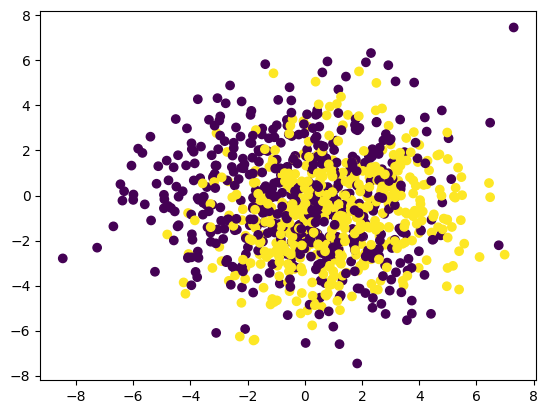

In [3]:
plt.scatter(X[:, 2], X[:, 3], c=y)

# Ансамбли: бустинги


Бустинг строится последовательно: каждое следующее дерево в нем обучается на основе результатов предыдущего, пытаясь уменьшить его ошибку. Как следствие, композиция будет иметь меньшее смещение, чем исходные базовые модели. Поэтому логично в качестве базовых моделей использовать те, которые изначально обладают небольшим разбросом и высоким смещением. Вопрос: какие это будут модели?
Еще одно соображение для выбора сильно смещенных моделей в том, что они банально быстрее учатся. Так как невозможно распараллелить обучение базовых моделей, то скорость их настройки становится серьезным вопросом. 

Что интересно, бустинги не очень хорошо работают с однородными данными - поэтому их нечасто применяют для текстов.

Расссмотрим квадратичную функцию потерь и композицию следующего вида: $ a = b_1 +  b_2 + ... + b_N $
Обучим только одно дерево $ a = b_1 $. Найдем примеры, для которых оно ошибается в  предсказании. Обучим для них еще одно дерево - $ b_2 $, которое будет предсказывать ошибку первого. Будем повторять это, пока не наберем K деревьев. Примерно так на верхнем уровне обучается бустинг. 


In [4]:
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

def eval_classifier(clf):
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=43)
    n_scores = cross_val_score(clf, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
    return np.mean(n_scores), np.std(n_scores)

In [5]:
results_accuracy = pd.DataFrame(0.0,
                                columns=["W/o ensembling", 'Bagging', "Bagging_with_mf", 'AdaBoost'],
                                index=['deep DTC', '1-level DTC', 'LR', 'SVC'])

In [6]:
acc_mean, acc_std = eval_classifier(DecisionTreeClassifier())

results_accuracy.loc['deep DTC', 'W/o ensembling'] = acc_mean
print(f"{acc_mean:.2f}, +- {acc_std:.2f}")

0.79, +- 0.05


In [7]:
acc_mean, acc_std = eval_classifier(DecisionTreeClassifier(max_depth=1))

results_accuracy.loc['1-level DTC', 'W/o ensembling'] = acc_mean
print(f"{acc_mean:.2f} +- {acc_std:.2f}")

0.68 +- 0.04


In [8]:
from sklearn.ensemble import BaggingClassifier

In [9]:
acc_mean, acc_std = eval_classifier(
    BaggingClassifier(DecisionTreeClassifier(), n_estimators=10, 
                      max_samples=1.0, max_features=1.0, 
                      bootstrap=True, bootstrap_features=False))

results_accuracy.loc['deep DTC', 'Bagging'] = acc_mean
print(f"{acc_mean:.2f}, {acc_std:.2f}")

0.86, 0.04


In [10]:
acc_mean, acc_std = eval_classifier(
    BaggingClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=10, 
                      max_samples=1.0, max_features=1.0, 
                      bootstrap=True, bootstrap_features=False))

results_accuracy.loc['1-level DTC', 'Bagging'] = acc_mean
print(f"{acc_mean:.2f}, {acc_std:.2f}")

0.69, 0.04


In [11]:
acc_mean, acc_std = eval_classifier(
    BaggingClassifier(DecisionTreeClassifier(), n_estimators=10, 
                      max_samples=1.0, max_features=0.8, 
                      bootstrap=True, bootstrap_features=False))

results_accuracy.loc['deep DTC', 'Bagging_with_mf'] = acc_mean
print(f"{acc_mean:.2f}, {acc_std:.2f}")

0.87, 0.04


In [12]:
acc_mean, acc_std = eval_classifier(
    BaggingClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=10, 
                      max_samples=1.0, max_features=0.8, 
                      bootstrap=True, bootstrap_features=False))

results_accuracy.loc['1-level DTC', 'Bagging_with_mf'] = acc_mean
print(f"{acc_mean:.2f}, {acc_std:.2f}")

0.68, 0.04


In [13]:
results_accuracy

,W/o ensembling,Bagging,Bagging_with_mf,AdaBoost
deep DTC,0.790000,0.861667,0.869,0.0
1-level DTC,0.683333,0.688667,0.684,0.0
LR,0.000000,0.000000,0.000,0.0
SVC,0.000000,0.000000,0.000,0.0


**Задание**: Дополните таблицу: обучите также логистическую регрессию с беггингом и без него.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier

acc_mean, acc_std = eval_classifier(LogisticRegression(random_state=43))
results_accuracy.loc['LR', 'W/o ensembling'] = acc_mean
print(f"Логистическая регрессия без ансамбля: {acc_mean:.2f} ± {acc_std:.2f}")

acc_mean, acc_std = eval_classifier(
    BaggingClassifier(LogisticRegression(random_state=43), n_estimators=10,
                      max_samples=1.0, max_features=1.0,
                      bootstrap=True, bootstrap_features=False))
results_accuracy.loc['LR', 'Bagging'] = acc_mean
print(f"Логистическая регрессия с бэггингом: {acc_mean:.2f} ± {acc_std:.2f}")

acc_mean, acc_std = eval_classifier(
    BaggingClassifier(LogisticRegression(random_state=43), n_estimators=10,
                      max_samples=1.0, max_features=0.8,
                      bootstrap=True, bootstrap_features=False))
results_accuracy.loc['LR', 'Bagging_with_mf'] = acc_mean
print(f"Логистическая регрессия с бэггингом (max_features=0.8): {acc_mean:.2f} ± {acc_std:.2f}")

results_accuracy

Логистическая регрессия без ансамбля: 0.81 ± 0.03
Логистическая регрессия с бэггингом: 0.81 ± 0.03
Логистическая регрессия с бэггингом (max_features=0.8): 0.81 ± 0.03


,W/o ensembling,Bagging,Bagging_with_mf,AdaBoost
deep DTC,0.790000,0.861667,0.869000,0.0
1-level DTC,0.683333,0.688667,0.684000,0.0
LR,0.811333,0.812000,0.810333,0.0
SVC,0.000000,0.000000,0.000000,0.0


## AdaBoost

AdaBoost обучает каждый следующий классификатор на объектах, на которых ошибаются предыдущие (объекты с ошибками получают больший вес, без ошибок — меньший).

In [15]:
from sklearn.ensemble import AdaBoostClassifier

In [16]:
acc_mean, acc_std = eval_classifier(
    AdaBoostClassifier(DecisionTreeClassifier(), n_estimators=50, learning_rate=1.0))

results_accuracy.loc['deep DTC', 'AdaBoost'] = acc_mean
print(f"{acc_mean:.2f}, {acc_std:.2f}")

0.79, 0.04


In [17]:
acc_mean, acc_std = eval_classifier(
    AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50, learning_rate=1.0))

results_accuracy.loc['1-level DTC', 'AdaBoost'] = acc_mean
print(f"{acc_mean:.2f}, {acc_std:.2f}")

0.81, 0.04


In [18]:
def highlight_max(s, props=''):
    return np.where(s == np.nanmax(s.values), props, '')

results_to_show = results_accuracy.copy()

results_to_show.style.apply(highlight_max, props='font-weight: bold;', axis=1).format('{:.3f}')

,W/o ensembling,Bagging,Bagging_with_mf,AdaBoost
deep DTC,0.790,0.862,0.869,0.795
1-level DTC,0.683,0.689,0.684,0.813
LR,0.811,0.812,0.810,0.000
SVC,0.000,0.000,0.000,0.000


**Задание:** выясните, дадут ли улучшение бэггинг и бустинг над линейной регрессией. Объясните, почему так.

In [19]:
acc_mean, acc_std = eval_classifier(
    AdaBoostClassifier(LogisticRegression(solver='liblinear', random_state=43), 
                       n_estimators=50, learning_rate=1.0))
results_accuracy.loc['LR', 'AdaBoost'] = acc_mean
print(f"AdaBoost с LR: {acc_mean:.2f} ± {acc_std:.2f}")

results_accuracy

AdaBoost с LR: 0.79 ± 0.04


,W/o ensembling,Bagging,Bagging_with_mf,AdaBoost
deep DTC,0.790000,0.861667,0.869000,0.795000
1-level DTC,0.683333,0.688667,0.684000,0.813000
LR,0.811333,0.812000,0.810333,0.788667
SVC,0.000000,0.000000,0.000000,0.000000


В данном случае бэггинг и бустинг не дают значимого улучшения.

Бэггинг (0.812) дал прирост всего на +0.001 по сравнению с одиночной моделью (0.811).

Bagging_with_mf (0.809) даже слегка ухудшил результат.

AdaBoost (0.789) оказался хуже, чем базовая логистическая регрессия.

Вопрос: Почему AdaBoost хуже работает на глубоких деревьях?

AdaBoost лучше работает с простыми базовыми моделями, такими как деревья с малой глубиной, так как они обеспечивают стабильность и позволяют ансамблю эффективно уменьшать смещение. Глубокие деревья, из-за их высокой дисперсии и склонности к переобучению, менее подходят для AdaBoost, что приводит к ухудшению производительности.

# Градиентный бустинг

Рассмотрим композицию $a = \sum_{i} {\gamma_i b_i}$. Для начала выбирается какой-нибудь простой $\gamma_0, b_0$ (например, 0 и среднее). Формально каждая N-ая модель, начиная со второй, пытается приблизиить антиградиент функционала ошибки, взятый в точках ${z_i=a_{N-1}(x_i)}$:
$$s_i = -\dfrac{\partial L(y, z)}{\partial z}|_{z=a_{N-1}}$$
Подбор алгоритма при этом производится, приближая эту ошибку c точки зрения квадратичной функции потерь.
$$ b_i = arg \min_{b \in \mathcal{B}} {\sum (b_i(x) - s_i)^2} $$

Градиентный бустинг - довольно мощная метамодель, с огромным количеством параметров и хитростей. Мы сегодня остановимся только на основных. Для начала рассмотрим самый стандартный бустинг с использованием деревьев решений (CART). Параметры базовых моделей такие же, как и раньше, но настройка амого бустинга довольно сложна!

Важный вопрос при обучении модели - какую функцию ошибок выбрать? Какая задача возникает при обработке датасета с вином?

Для того, чтобы оценивать модель, полезны различные метрики - численные характеристики ее качества. При этом бустинги настолько галантны, что предоставляют нам возможность оценивать метрики прямо при обучении. Для этого необходимо задать тип метрики в конструкторе и eval_set при запуске fit().

На практике обычно используется один из трех вариантов бустинга - Xgboost, LightGBM или CatBoost.

### [XGBoost](https://www.kdd.org/kdd2016/papers/files/rfp0697-chenAemb.pdf).
Плюсы:
- Позволяет легко паралелить вычисления (например на спарке)
- Легко использовать с sklearn и numpy (но с потерей производительности)
- Поддерживается обработка разреженных данных
- Предсортированные блоки, кэши, шардирование

Минусы:
- Нет поддержки GPU

[документация](https://xgboost.readthedocs.io/en/latest/)

  
### [LightGBM](https://papers.nips.cc/paper/2017/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf)
Плюсы:
- Поддержка GPU
- Метод Фишера для работы с категориальными признаками
- Уменьшение размера обучающей выборки (GOSS)
- Объединение разреженных признаков (EFB)

Минусы:
- Итерфейс не совместим с sklearn/numpy

[документация](https://lightgbm.readthedocs.io/en/latest/Python-API.html)

### [CatBoost](https://papers.nips.cc/paper/2017/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf)
Плюсы:
- Поддержка GPU
- Легко использовать с sklearn и numpy
- Более продвинутая работа с категориальными фичами
- Наши слоны
  
Минусы:
- Бывает работает хуже (возможно слабее эвристики), но с категориальными фичами — хорошо

[документация](https://catboost.ai/docs/concepts/python-quickstart.html)


In [20]:
from catboost import CatBoostClassifier

acc_mean, acc_std = eval_classifier(
    CatBoostClassifier(
        iterations=10,
        depth=1,
        learning_rate=1,
        loss_function='Logloss',
        verbose=True, 
        task_type='CPU'))

сat_boost = acc_mean

results_accuracy.loc['1-level DTC', 'CatBoost'] = acc_mean
print(f"{acc_mean:.2f}, {acc_std:.2f}")

0.76, 0.04


In [21]:
from catboost import CatBoostClassifier

acc_mean, acc_std = eval_classifier(
    CatBoostClassifier(
        iterations=10,
        learning_rate=1,
        loss_function='Logloss',
        verbose=True, 
        task_type='CPU'))

сat_boost = acc_mean

results_accuracy.loc['deep DTC', 'CatBoost'] = acc_mean
print(f"{acc_mean:.2f}, {acc_std:.2f}")

0.86, 0.03


In [22]:
from xgboost import XGBClassifier
acc_mean, acc_std = eval_classifier(XGBClassifier(objective='binary:logistic', random_state=42))

xg_boost = acc_mean
print(f"{acc_mean:.2f}, {acc_std:.2f}")

results_accuracy.loc['deep DTC', 'XGBoost'] = acc_mean

0.92, 0.03


In [23]:
acc_mean, acc_std = eval_classifier(XGBClassifier(objective='binary:logistic', max_depth=1, random_state=42))

xg_boost = acc_mean
print(f"{acc_mean:.2f}, {acc_std:.2f}")

results_accuracy.loc['1-level DTC', 'XGBoost'] = acc_mean

0.84, 0.03


In [24]:
results_to_show = results_accuracy.copy()
results_to_show.style.apply(highlight_max, props='font-weight: bold;', axis=1).format('{:.3f}')

,W/o ensembling,Bagging,Bagging_with_mf,AdaBoost,CatBoost,XGBoost
deep DTC,0.790,0.862,0.869,0.795,0.862,0.920
1-level DTC,0.683,0.689,0.684,0.813,0.759,0.841
LR,0.811,0.812,0.810,0.789,nan,nan
SVC,0.000,0.000,0.000,0.000,nan,nan


In [25]:
import lightgbm as lgb

train_data = lgb.Dataset(X, label=y)

param = {'num_leaves': 31, 
         'objective': 'multiclass', 
         'num_class': 2, 
         'metric': ['multi_logloss']}

num_round = 10
boost = lgb.train(param, train_data, num_boost_round=10)

lg_boost = (boost.predict(X).argmax(axis=-1) == y).mean()

results_accuracy.loc['deep DTC', 'LightGBM'] = lg_boost
print(f"{lg_boost:.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1000, number of used features: 20
[LightGBM] [Info] Start training from score -0.689155
[LightGBM] [Info] Start training from score -0.697155
0.95


In [26]:
results_to_show = results_accuracy.copy()

results_to_show.style.apply(highlight_max, props='font-weight: bold;', axis=1).format('{:.3f}')

,W/o ensembling,Bagging,Bagging_with_mf,AdaBoost,CatBoost,XGBoost,LightGBM
deep DTC,0.790,0.862,0.869,0.795,0.862,0.920,0.947
1-level DTC,0.683,0.689,0.684,0.813,0.759,0.841,nan
LR,0.811,0.812,0.810,0.789,nan,nan,nan
SVC,0.000,0.000,0.000,0.000,nan,nan,nan


## Пример
Рассмотрим реальный датасет, и на его примере попробуем поработать с бустингом.

In [27]:
df = pd.read_csv('diabetes.csv')

X = df.drop(columns='Outcome')
Y = df['Outcome'] 

X_train, X_test, y_train, y_test = train_test_split(X, Y, train_size=0.5, test_size=0.5)

In [28]:
model = XGBRegressor(n_estimators=100, learning_rate=1, seed=SEED)
fit_params = {"eval_set":[(X_train, y_train),(X_test, y_test)], "verbose": False}
model.fit(X_train, y_train,
            eval_set=[(X_train, y_train),(X_test, y_test)],
            verbose=False)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [29]:
results = model.evals_result()

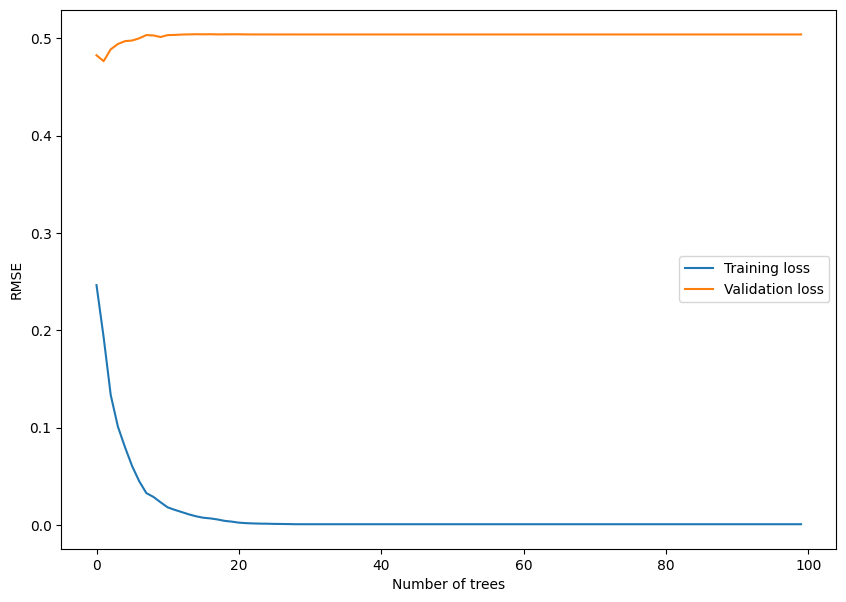

In [30]:
error_function = "rmse"
plt.figure(figsize=(10,7))
plt.plot(results["validation_0"][error_function], label="Training loss")
plt.plot(results["validation_1"][error_function], label="Validation loss")
plt.xlabel("Number of trees")
plt.ylabel("RMSE")
plt.legend()

Как мы видим, хотя лосс при обучении падал и падал, на валидации метрики перестали улучшаться довольно рано. Это довольно плохой знак. Однако говорит ли это о катастрофической ситуации? Проверим переобучение с помощью кросс-валидации.

In [31]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model, X, Y, cv=10, scoring=["neg_root_mean_squared_error"],
                            return_train_score=True)
print("Train RMSE is", -cv_results['train_neg_root_mean_squared_error'].mean())
print("Test RMSE is", -cv_results['test_neg_root_mean_squared_error'].mean())

Train RMSE is 0.000744145450880751
Test RMSE is 0.5135758578777313


Кажется, у нас действительно серьезные проблемы. Попробуем уменьшить скорость обучения.


In [32]:
# train and eval model with smaller lr
model = XGBRegressor(n_estimators=100, learning_rate=0.01, seed=SEED)
fit_params = {"eval_set":[(X_train, y_train),(X_test, y_test)], "verbose": False}
# Add verbose=False to avoid printing out updates with each cycle
model.fit(X_train, y_train,
            eval_set=[(X_train, y_train),(X_test, y_test)],
            verbose=False)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


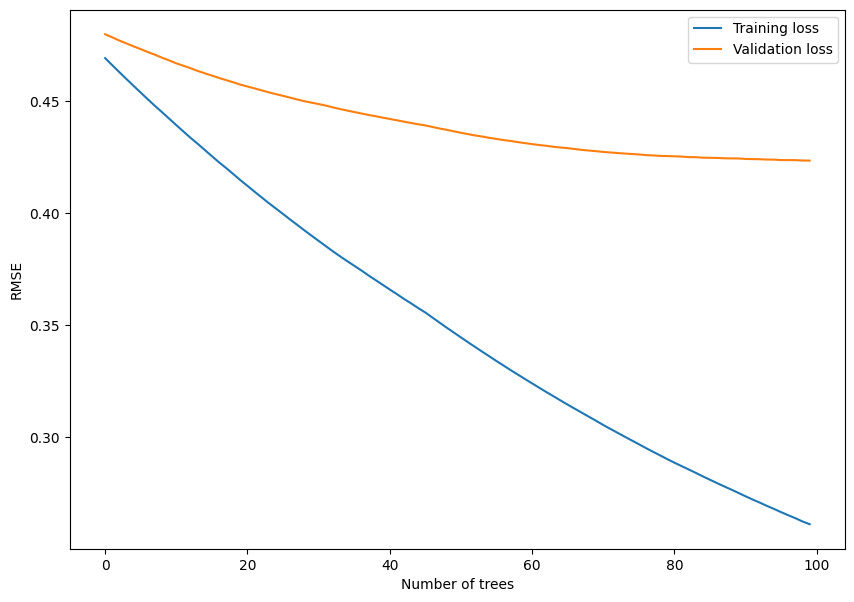

In [33]:
# plot results
results = model.evals_result()
error_function = "rmse"
plt.figure(figsize=(10,7))
plt.plot(results["validation_0"][error_function], label="Training loss")
plt.plot(results["validation_1"][error_function], label="Validation loss")
plt.xlabel("Number of trees")
plt.ylabel("RMSE")
plt.legend()

Помогло ли это? Попробуем получить результаты лучше, поиграв с параметрами.

In [34]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model, X, Y, cv=10, scoring=["neg_root_mean_squared_error"],
                            return_train_score=True)
print("Train RMSE is", -cv_results['train_neg_root_mean_squared_error'].mean())
print("Test RMSE is", -cv_results['test_neg_root_mean_squared_error'].mean())


Train RMSE is 0.31414556205272676
Test RMSE is 0.40764451324939727


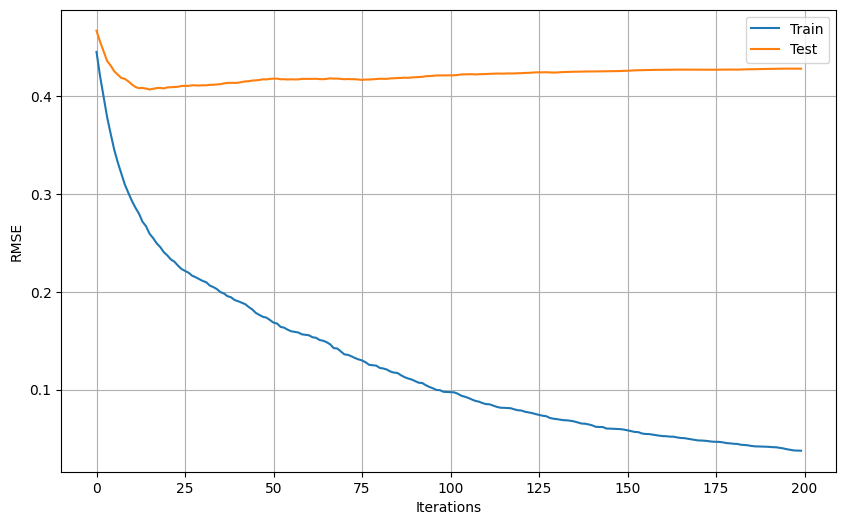

In [35]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    seed=SEED
)

fit_params = {"eval_set": [(X_train, y_train), (X_test, y_test)], "verbose": False}

model.fit(X_train, y_train, **fit_params)
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x, results['validation_0']['rmse'], label='Train')
plt.plot(x, results['validation_1']['rmse'], label='Test')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

Так как параметров довольно много, может быть разумно автоматизировать их поиск. Для этого воспользуемся поиском по решетке.

In [36]:
from sklearn.model_selection import GridSearchCV

xgboost_params = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgboost_best_grid = GridSearchCV(model, xgboost_params, cv=7, n_jobs=-1, return_train_score=True)

xgboost_best_grid.fit(X_train, y_train, **fit_params)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,7
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,objective,'reg:squarederror'


In [37]:
print(xgboost_best_grid.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50, 'subsample': 0.6}


Давайте проверим, какую точность мы получим с лучшими параметрами.

In [38]:
best_model = xgboost_best_grid.best_estimator_

cv_results = cross_validate(best_model, X, Y, cv=7, scoring=["neg_root_mean_squared_error"], return_train_score=True)

print("Train RMSE:", -cv_results['train_neg_root_mean_squared_error'].mean())
print("Test RMSE:", -cv_results['test_neg_root_mean_squared_error'].mean())

Train RMSE: 0.31989267468452454
Test RMSE: 0.3969784038407462


**Задание:** Проведите обучение и с LightGBM/CatBoost. Какие лучшие точности у вас получилось получить?

In [39]:
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, cross_validate

lgb_params = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
}

cat_params = {
    'depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'iterations': [50, 100, 200],
    'subsample': [0.6, 0.8, 1.0],
    'rsm': [0.6, 0.8, 1.0]
}

lgb_model = LGBMRegressor(random_state=SEED, verbose=-1)
lgb_grid = GridSearchCV(lgb_model, lgb_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
lgb_grid.fit(X_train, y_train, eval_set=[(X_test, y_test)])
lgb_best_model = lgb_grid.best_estimator_

cv_lgb = cross_validate(lgb_best_model, X, Y, cv=5, scoring=["neg_root_mean_squared_error"], return_train_score=True)
print("LightGBM Best Parameters:", lgb_grid.best_params_)
print("LightGBM - Train RMSE:", -cv_lgb['train_neg_root_mean_squared_error'].mean())
print("LightGBM - Test RMSE:", -cv_lgb['test_neg_root_mean_squared_error'].mean())

cat_model = CatBoostRegressor(loss_function='RMSE', random_seed=SEED, verbose=False)
cat_grid = GridSearchCV(cat_model, cat_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
cat_grid.fit(X_train, y_train, eval_set=(X_test, y_test))
cat_best_model = cat_grid.best_estimator_

cv_cat = cross_validate(cat_best_model, X, Y, cv=5, scoring=["neg_root_mean_squared_error"], return_train_score=True)
print("CatBoost Best Parameters:", cat_grid.best_params_)
print("CatBoost - Train RMSE:", -cv_cat['train_neg_root_mean_squared_error'].mean())
print("CatBoost - Test RMSE:", -cv_cat['test_neg_root_mean_squared_error'].mean())

LightGBM Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
LightGBM - Train RMSE: 0.33199930024772273
LightGBM - Test RMSE: 0.3964844494737318
CatBoost Best Parameters: {'depth': 3, 'iterations': 50, 'learning_rate': 0.2, 'rsm': 0.6, 'subsample': 0.6}
CatBoost - Train RMSE: 0.34863084417648854
CatBoost - Test RMSE: 0.39671731490287543


**Задание:** Постройте графики предсказаний для первых двух PCA фичей для бустингов разной глубины/разного числа деревьев.

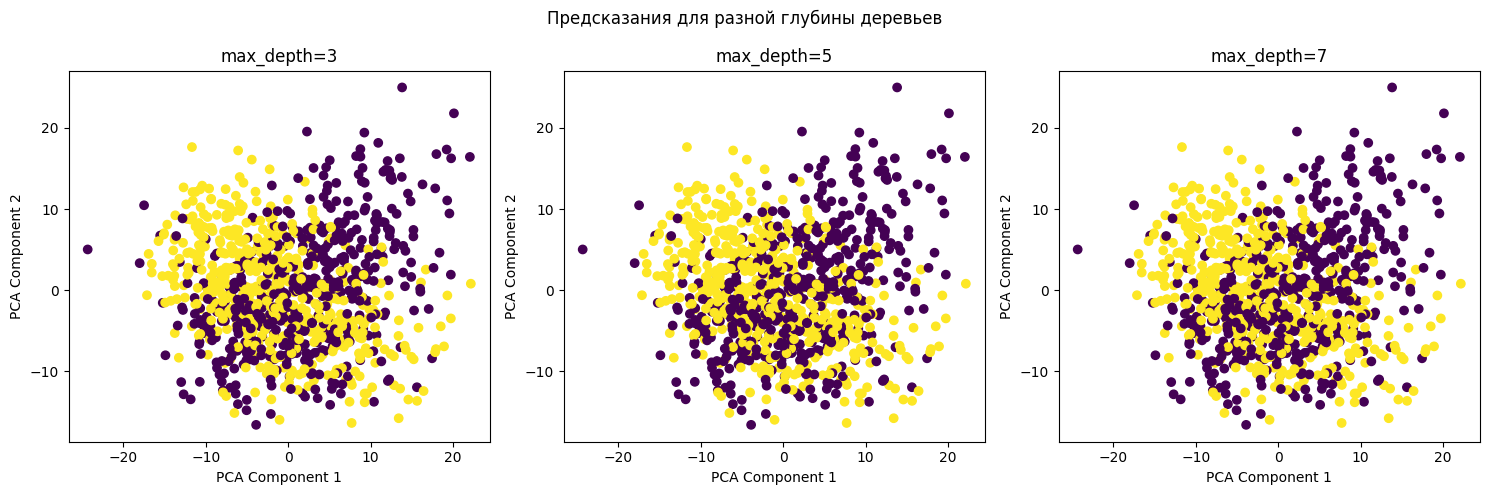

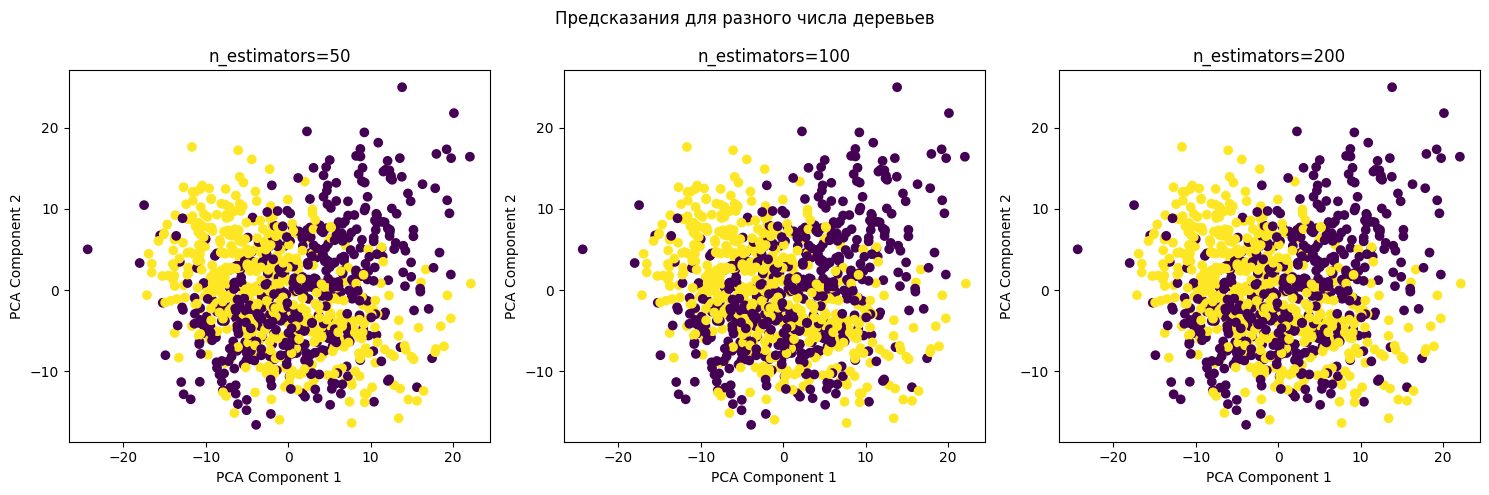

In [40]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, 
                           n_redundant=5, random_state=42)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

depths = [3, 5, 7]
n_estimators_list = [50, 100, 200]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, depth in enumerate(depths):
    model = XGBClassifier(max_depth=depth, n_estimators=100, random_state=314159)
    model.fit(X, y)
    predictions = model.predict(X)
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=predictions, cmap='viridis')
    axes[i].set_title(f'max_depth={depth}')
    axes[i].set_xlabel('PCA Component 1')
    axes[i].set_ylabel('PCA Component 2')
plt.suptitle('Предсказания для разной глубины деревьев')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, n_estimators in enumerate(n_estimators_list):
    model = XGBClassifier(max_depth=4, n_estimators=n_estimators, random_state=314159)
    model.fit(X, y)
    predictions = model.predict(X)
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=predictions, cmap='viridis')
    axes[i].set_title(f'n_estimators={n_estimators}')
    axes[i].set_xlabel('PCA Component 1')
    axes[i].set_ylabel('PCA Component 2')
plt.suptitle('Предсказания для разного числа деревьев')
plt.tight_layout()
plt.show()

**Задание**: Постройте график зависимости точности от глубины

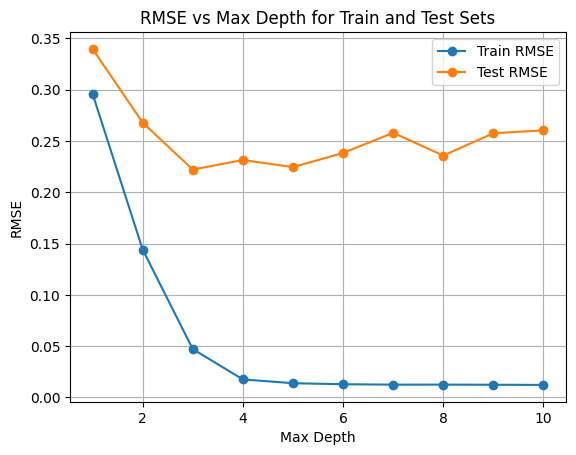

In [43]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBClassifier
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
train_rmse = []
test_rmse = []

for depth in depths:
    model = XGBClassifier(max_depth=depth, n_estimators=100, random_state=314159)
    model.fit(X_train, y_train)
    
    train_pred_proba = model.predict_proba(X_train)[:, 1]
    test_pred_proba = model.predict_proba(X_test)[:, 1]
    
    train_rmse.append(np.sqrt(mean_squared_error(y_train, train_pred_proba)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, test_pred_proba)))

plt.plot(depths, train_rmse, label='Train RMSE', marker='o')
plt.plot(depths, test_rmse, label='Test RMSE', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.title('RMSE vs Max Depth for Train and Test Sets')
plt.legend()
plt.grid(True)
plt.show()